# Global Tech Layoffs Analysis (2020–2026)

Analysis of ~4,500 layoff events across the global tech industry, examining patterns by 
industry, country, time, company stage, and funding relationship. Includes a deep dive into 
layoff concentration using Pareto analysis.

**Dataset:** [Layoffs 2022](https://www.kaggle.com/datasets/swaptr/layoffs-2022) (Kaggle)

**Skills demonstrated:** data cleaning (missing values, whitespace, date parsing, anomaly 
detection), groupby aggregation, correlation analysis, Pareto/concentration analysis, and 
data visualization with matplotlib/seaborn.

**Key question explored:** Are tech layoffs broadly distributed across the industry, or 
concentrated among a small number of major companies?

## this is my initial data inspection step

In [91]:
import pandas as pd 
df=pd.read_csv('C:\\Users\\Platonic\\Downloads\\archive\\layoffs.csv')
print(df.duplicated().sum())
print(df['industry'].unique())
print(df['stage'].unique())
print(df['company'].str.strip().ne(df['company']).sum())

0
<StringArray>
[          'Data',             'HR',     'Recruiting',     'Healthcare',
       'Consumer',         'Crypto',      'Marketing',       'Security',
         'Retail', 'Transportation',         'Travel',        'Finance',
          'Media',        'Support',    'Real Estate',             'AI',
           'Food',          'Sales',  'Manufacturing',          'Other',
      'Education',        'Product',      'Logistics', 'Infrastructure',
       'Hardware',        'Fitness',         'Energy',          'Legal',
              nan,      'Aerospace',   'Construction']
Length: 31, dtype: str
<StringArray>
[       'Unknown',       'Series F',       'Series C',           'Seed',
       'Acquired',       'Series D',       'Post-IPO',       'Series A',
 'Private Equity',     'Subsidiary',       'Series E',       'Series B',
       'Series G',       'Series H',       'Series J',       'Series I',
              nan]
Length: 17, dtype: str
16


## Cleaning whitespace issues
Company names may have leading/trailing spaces which would cause 
grouping issues later (e.g. "Amazon " being treated separately from "Amazon")

In [92]:



# Clean whitespace from all text columns
text_columns = ['company', 'location', 'country', 'industry', 'stage', 'source']

for col in text_columns:
    df[col] = df[col].str.strip()

# Verify cleaning worked (excluding NaN to avoid false positives)
for col in text_columns:
    clean = df[col].dropna()
    count = clean.str.strip().ne(clean).sum()
    print(f"{col}: {count} remaining whitespace issues")

company: 0 remaining whitespace issues
location: 0 remaining whitespace issues
country: 0 remaining whitespace issues
industry: 0 remaining whitespace issues
stage: 0 remaining whitespace issues
source: 0 remaining whitespace issues


## Next up fixing date and date_added 
they are still stored in plain texts instead of actual dates 

## Handling date inconsistencies
Found 35 rows where `date_added` occurs before `date`. Rather than dropping 
these rows or assuming they're errors, I flagged them with a new boolean 
column `date_anomaly`. This is likely due to reporting lag or later record 
updates rather than data corruption, since most gaps are small (1-20 days). 
Flagging preserves the data while making the inconsistency visible for 
anyone doing further analysis.

In [93]:

df['date']=pd.to_datetime(df['date'])
df['date_added']=pd.to_datetime(df['date_added'])

df['date'].dt.year
df['date'].dt.month
df.sort_values('date')

df[['date','date_added']].dtypes
print(df['date'].min())
print(df['date'].max())

print(df['date_added'].min())
print(df['date_added'].max())
#checking if there are dates added before the actual layoff dates 
(df['date_added'] < df['date']).sum()

bad_dates = df[df['date_added'] < df['date']]
bad_dates[['company', 'date', 'date_added']]
#storing the anomalies in a separate column for a cleaner look
df['date_anomaly'] = df['date_added'] < df['date']

2020-03-11 00:00:00
2026-06-26 00:00:00
2020-03-28 00:00:00
2026-06-27 00:00:00


## Missing value assessment
 `total_laid_off`: 34.53% missing
 `percentage_laid_off`: 37.20% missing
 `funds_raised`: 11.70% missing

These columns are left as NaN rather than filled with 0 or the mean. A missing 
`total_laid_off` does not mean zero people were laid off,it means the 
source report didn't specify a number. Filling with 0 or an average would 
misrepresent the data and distort any aggregate analysis. Missing values 
are excluded automatically by pandas during aggregation (sum, mean, etc.), 
which is the correct behavior here.

In [94]:

missingsummary=df[['total_laid_off','percentage_laid_off','funds_raised']].isnull().sum()
missingpercent=(missingsummary/len(df))*100
print(missingsummary)
print(missingpercent.round(2))

total_laid_off         1549
percentage_laid_off    1669
funds_raised            525
dtype: int64
total_laid_off         34.53
percentage_laid_off    37.20
funds_raised           11.70
dtype: float64


## Which industries had the most total layoffs?

In [95]:

industrylayoffs=df.groupby('industry')['total_laid_off'].sum().sort_values(ascending=False).head(10)
industrylayoffs.head(10)

industry
Other             119830.0
Retail            106706.0
Hardware          106261.0
Consumer           97399.0
Finance            69912.0
Transportation     67602.0
Food               52101.0
Healthcare         39462.0
Infrastructure     24835.0
Travel             24140.0
Name: total_laid_off, dtype: float64

Insight: Retail and Hardware together account for over 200K layoffs consumer-facing and physical-product industries appear to have been hit hardest, likely reflecting post-pandemic shifts (less in-person retail, hardware oversupply after the 2021-2022 tech buying boom cooled off). Worth noting "Other" topping the list is a data limitation.It's a catch-all category masking what industries are actually inside it.

## Which countries were hit hardest?

In [96]:

country_layoffs=df.groupby('country')['total_laid_off'].sum().sort_values(ascending=False)
country_layoffs.head(10)

country
United States     660173.0
India              66789.0
Germany            32055.0
United Kingdom     24594.0
Netherlands        21975.0
Sweden             20379.0
Canada             16068.0
Israel             14819.0
Brazil             11939.0
China               8190.0
Name: total_laid_off, dtype: float64

Insight: The US accounts for roughly 10x the layoffs of the second-highest country (India). This makes sense given the dataset likely skews toward Western/US-tracked tech and business news sources.But there also exists a "data collection bias". Since most of the data was collected from the US and the source had more asseccibilty towards that region this might not be the actual global layoff stat.

## Yearly Layoff Trend

In [97]:

df['year']=df['date'].dt.year
yearly_layoffs=df.groupby('year')['total_laid_off'].sum().sort_values(ascending=False)
yearly_layoffs.head(10)

year
2023    265660.0
2022    165269.0
2024    152922.0
2025    124636.0
2026    122268.0
2020     80998.0
2021     15823.0
Name: total_laid_off, dtype: float64

Insight: 2023 was by far the peak year ,nearly double 2022, and 2021 was almost negligible by comparison. This lines up with the real-world "tech correction" story: 2021 was a hiring boom (COVID stimulus + remote work surge), then rates rose, funding tightened, and 2022-2023 saw the wave of layoffs correcting for that overhiring. 2024-2026 staying elevated (120K+ each year) suggests this wasn't a one-time correction,it became a sustained trend, not a single shock.

## Which company stages saw the most layoffs?

In [98]:
stage_values=df.groupby('stage')['total_laid_off'].sum().sort_values(ascending=False)
stage_values.head(10)

stage
Post-IPO          586143.0
Unknown            81996.0
Acquired           73687.0
Series B           32440.0
Series C           27769.0
Series D           27539.0
Series E           25414.0
Series F           16761.0
Private Equity     14320.0
Series A            9247.0
Name: total_laid_off, dtype: float64

Insight: Post-IPO companies dominate by a massive margin , nearly 7x the next closest category. This makes sense structurally: public companies are simply bigger (more employees to cut from), face direct pressure from shareholders/quarterly earnings to control costs, and their layoffs get reported more reliably than a private startup's. Compare this to the earlier-stage rows (Series A-F) layoffs scale up roughly with funding stage, which tracks with company size growing as they raise more rounds.
Limitation: This metric is somewhat biased by company size, not necessarily by which stage is "worst hit."

## Relationship between funds raised and layoff size

In [99]:
correlation = df['funds_raised'].corr(df['total_laid_off'])
print(correlation)

0.11989761880297334


What This Actually Means:
A correlation of 0.12 is very close to zero — meaning funds raised and layoff size are essentially unrelated in this dataset. Companies that raised a lot of money weren't meaningfully more or less likely to have large layoffs than companies that raised very little.
Limitation: correlation only captures linear relationships. It's possible there's a more complex pattern (e.g. only extremely high-funded companies show a pattern) that a simple correlation wouldn't catch

## Which companies had the biggest impact?
The stage-based analysis showed Post-IPO companies dominate total layoffs, but that could 
mean either "many companies had moderate layoffs" or "a handful of mega-companies inflate 
the total." Breaking down by individual company clarifies which story is actually true.

In [100]:
top_companies = df.groupby('company')['total_laid_off'].sum().sort_values(ascending=False).head(15)
print(top_companies)
top_15_sum = top_companies.sum()
total_sum = df['total_laid_off'].sum()
percentage = (top_15_sum / total_sum) * 100
print(f"Top 15 companies account for {percentage:.2f}% of all layoffs")

company
Amazon        58124.0
Intel         43115.0
Meta          35700.0
Oracle        31294.0
Microsoft     30055.0
Dell          23650.0
Cisco         18521.0
Salesforce    16611.0
Tesla         14500.0
Google        13697.0
SAP           11000.0
Ericsson      10100.0
Philips       10000.0
PayPal         9428.0
Flink          8100.0
Name: total_laid_off, dtype: float64
Top 15 companies account for 36.00% of all layoffs


Insight: The top 15 companies alone account for 36% of total layoffs, despite representing 
a tiny fraction of the 1,500+ unique companies in the dataset. Critically, nearly all of 
these are massive Post-IPO tech giants (Amazon, Intel, Meta, Oracle, Microsoft, Google...), 
which reframes the earlier stage-based finding: Post-IPO layoffs aren't broadly distributed 
across many public companies, they're concentrated in a small number of the largest tech 
firms. This suggests layoffs during this period were less about "public company pressure" 
broadly and more about a handful of major players correcting specific overhiring.

## Layoff Concentration Analysis (Pareto Principle)
Testing whether layoffs are evenly distributed across companies, or concentrated among a small number of major players.

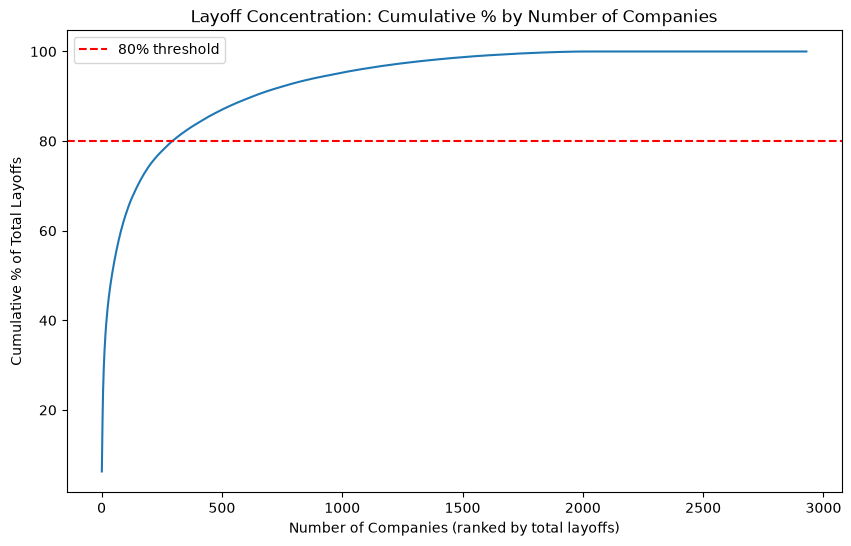

In [101]:
company_layoffs = df.groupby('company')['total_laid_off'].sum().sort_values(ascending=False)
cumulative_pct = (company_layoffs.cumsum() / company_layoffs.sum()) * 100

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_pct) + 1), cumulative_pct.values)
plt.axhline(y=80, color='r', linestyle='--', label='80% threshold')
plt.title('Layoff Concentration: Cumulative % by Number of Companies')
plt.xlabel('Number of Companies (ranked by total layoffs)')
plt.ylabel('Cumulative % of Total Layoffs')
plt.legend()
plt.show()

In [102]:
threshold_company_count = (cumulative_pct >= 80).idxmax()
threshold_rank = cumulative_pct.index.get_loc(threshold_company_count) + 1
print(f"It takes {threshold_rank} companies to reach 80% of total layoffs")
print(f"Total unique companies in dataset: {len(company_layoffs)}")

It takes 294 companies to reach 80% of total layoffs
Total unique companies in dataset: 2929


Insight: Despite 2,929 unique companies in the dataset, just 294 companies (roughly 10%) 
account for 80% of all layoffs. This confirms the earlier finding involving mega-companies 
like Amazon and Intel: layoffs in this dataset are not evenly distributed across the tech 
industry, they are heavily concentrated among a relatively small subset of large, established 
players. This has a practical implication: broad narratives like "the tech industry cut X jobs" 
can be misleading, since roughly 10% of companies are driving the vast majority of the total. 
This also reframes the earlier stage-based finding (Post-IPO dominance) ,it isn't that public 
companies broadly struggled more, but that a concentrated group of the largest public companies 
drove most of the volume.

## Personal Recommendation 
- Track layoff exposure at the "top 300 company" level, not industry-wide. Industry aggregates hide concentration risk
- Don't use funding round as a layoff-risk predictor .It has no real signal here

## Visualization: Top 10 Industries by Total Layoffs

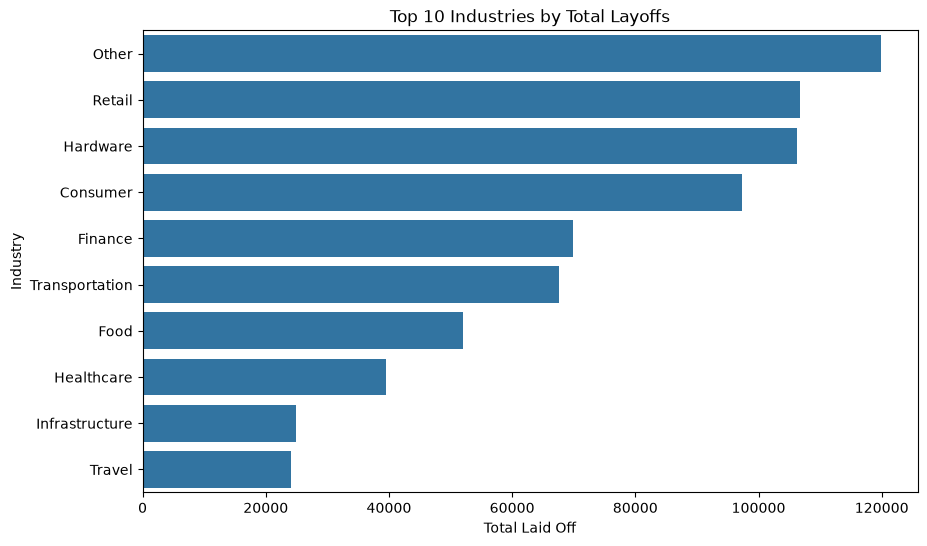

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))          # sets the size of the chart (width, height)
sns.barplot(x=industrylayoffs.values, y=industrylayoffs.index)   # x = numbers, y = category names
plt.title('Top 10 Industries by Total Layoffs')
plt.xlabel('Total Laid Off')
plt.ylabel('Industry')
plt.show()                           # actually displays the chart

## Visualization: Top 10 Countries by Total Layoffs

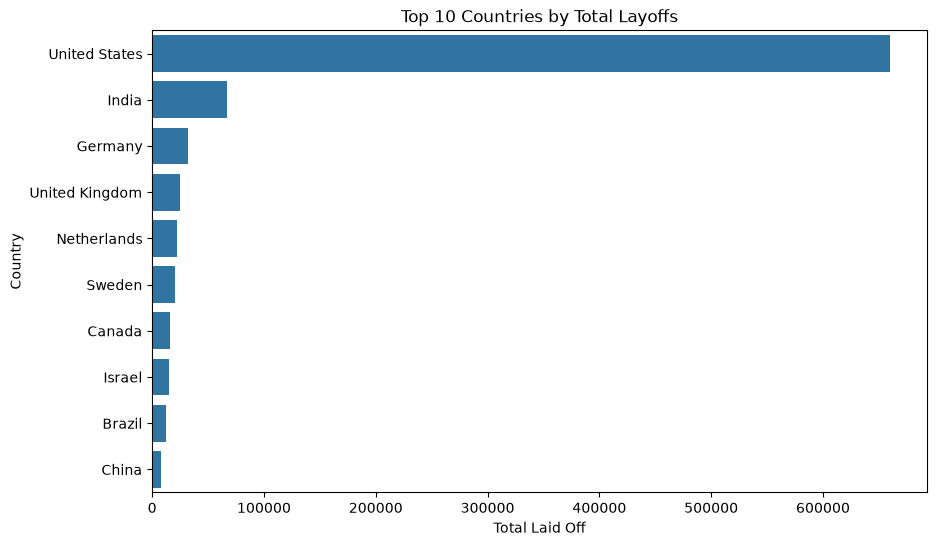

In [104]:
country_layoffs = df.groupby('country')['total_laid_off'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=country_layoffs.values, y=country_layoffs.index)
plt.title('Top 10 Countries by Total Layoffs')
plt.xlabel('Total Laid Off')
plt.ylabel('Country')
plt.show()

## Visualization: Layoffs Trend by Year

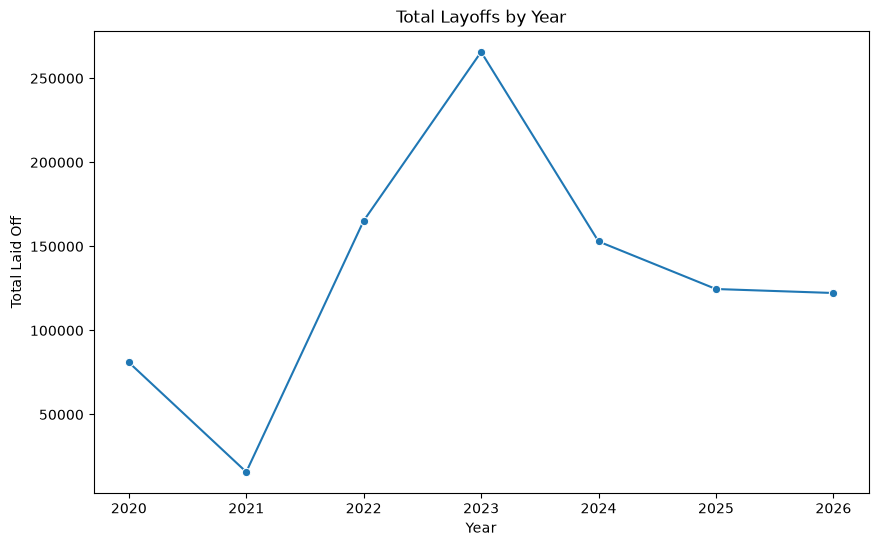

In [105]:
yearly_layoffs = df.groupby('year')['total_laid_off'].sum().sort_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x=yearly_layoffs.index, y=yearly_layoffs.values, marker='o')
plt.title('Total Layoffs by Year')
plt.xlabel('Year')
plt.ylabel('Total Laid Off')
plt.show()

## Key Findings

- **Retail and Hardware** were hit hardest by industry (~106-107K layoffs each), likely 
  reflecting post-pandemic retail contraction and hardware oversupply following the 2021-2022 
  buying boom.
- **The US accounts for ~10x the layoffs of India** (the #2 country), though this is likely 
  a data collection bias toward Western-tracked sources rather than a true global proportion.
- **2023 was the peak year** (265K layoffs), nearly double 2022, with elevated levels 
  (120K+/year) persisting through 2024-2026 suggesting a sustained industry correction 
  rather than a single shock.
- **Layoffs are heavily concentrated**: just 294 of 2,929 companies (~10%) account for 80% 
  of all layoffs, with Amazon alone responsible for over 6% of the dataset's total. This 
  reframes the earlier stage-based finding "Post-IPO dominance" isn't broad public-company 
  struggle, but a small cluster of mega-companies driving most of the volume.
- **Funds raised shows almost no correlation with layoff size** (r = 0.12), challenging the 
  intuitive assumption that heavily-funded companies overhired and therefore cut more.

## Limitations

- ~35% of records are missing exact headcount figures (`total_laid_off`), meaning totals in 
  this analysis likely understate true layoff volume.
- Country-level findings are likely skewed by the dataset's sourcing, which appears to favor 
  Western/US-based reporting.
- The "Other" industry category (the single largest by volume) is a catch-all that obscures 
  what specific industries are actually driving that total, a good candidate for further 
  investigation.

## Next Steps

- Break down the "Other" industry category into more specific groupings
- Explore whether the top 294 companies show clustering by timing (did they all cut around 
  the same time, suggesting industry-wide herd behavior?)
- Cross-reference with stock price or hiring data to test whether layoffs followed periods 
  of rapid overhiring